# Anisotropy in the Quark Gluon Plasma

<img src="https://raw.githubusercontent.com/illinois-mlp/MachineLearningForPhysics/main/img/Project_AnisotropyQGP-Figure.png" width=400 align=left></img><br>

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np
import pandas as pd
import os.path
import subprocess
import h5py
from scipy.optimize import minimize
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

## <span style="color:Orange">Overview</span>

The Quark Gluon Plasma is a deconfined state of matter created in heavy ion collisions in the Large Hadron Collider. In this project you will learn how to characterize the shapes of the quark gluon plasma produced in these collisions, and leverage the shapes to characterize how particles lose energy while traversing through the medium.

## <span style="color:Orange">Data Sources</span>

The data for this project can be found at:
* https://courses.physics.illinois.edu/phys498mlp/sp2024/data/projects/AnisotropyQGP/events.hdf

Jet Energy information:
* https://courses.physics.illinois.edu/phys498mlp/sp2024/data/projects/AnisotropyQGP/jet_energy.txt

TRENTO heavy ion initial states:
* http://qcd.phy.duke.edu/trento/examples.html

## <span style="color:Orange">Questions</span>

### <span style="color:LightGreen">Question 01</span>

One of the most important signals of the quark gluon plasma in heavy ion collisions is the presence of "azimuthal anisotropy." Azimuthal anisotropy in heavy ion collisions is quantified by $v_n$, the coefficients in a fourier series fit to momentum deposits in particle detectors. Using equations (1) and (2) in https://arxiv.org/pdf/0809.2949.pdf, write a method to evaluate $v_n$ for an array of particles and angles. Assume the $\delta_n$ in equation 2 is 0 -- the term comes from correlated particle decays which we will not consider in this project.



In [2]:
def vn(n, particles):
    energies = particles[:, 0]
    angles   = particles[:, 1]
    total_energy = np.sum(energies)
    Qn_real = np.sum(energies * np.cos(n * angles))
    Qn_imag = np.sum(energies * np.sin(n * angles))
    v = np.sqrt(Qn_real**2 + Qn_imag**2) / total_energy
    return v


### <span style="color:LightGreen">Question 02</span>

Azimuthal anisotropy in heavy ion collisions arises because of asymmetry in the initial states of heavy ion collisions. These initial states can be modeled by software like TRENTO.


http://qcd.phy.duke.edu/trento/index.html

https://arxiv.org/pdf/1412.4708.pdf


Using the "Examples" in the documentation, read and produce images of some TRENTO PbPb events. They should be found in the TRENTO data file. In a couple sentences, write about the dimensions of this data: how do we quantify the QGP initial state? What units are used for position within the event, and what's the "z" axis on all of these plots?

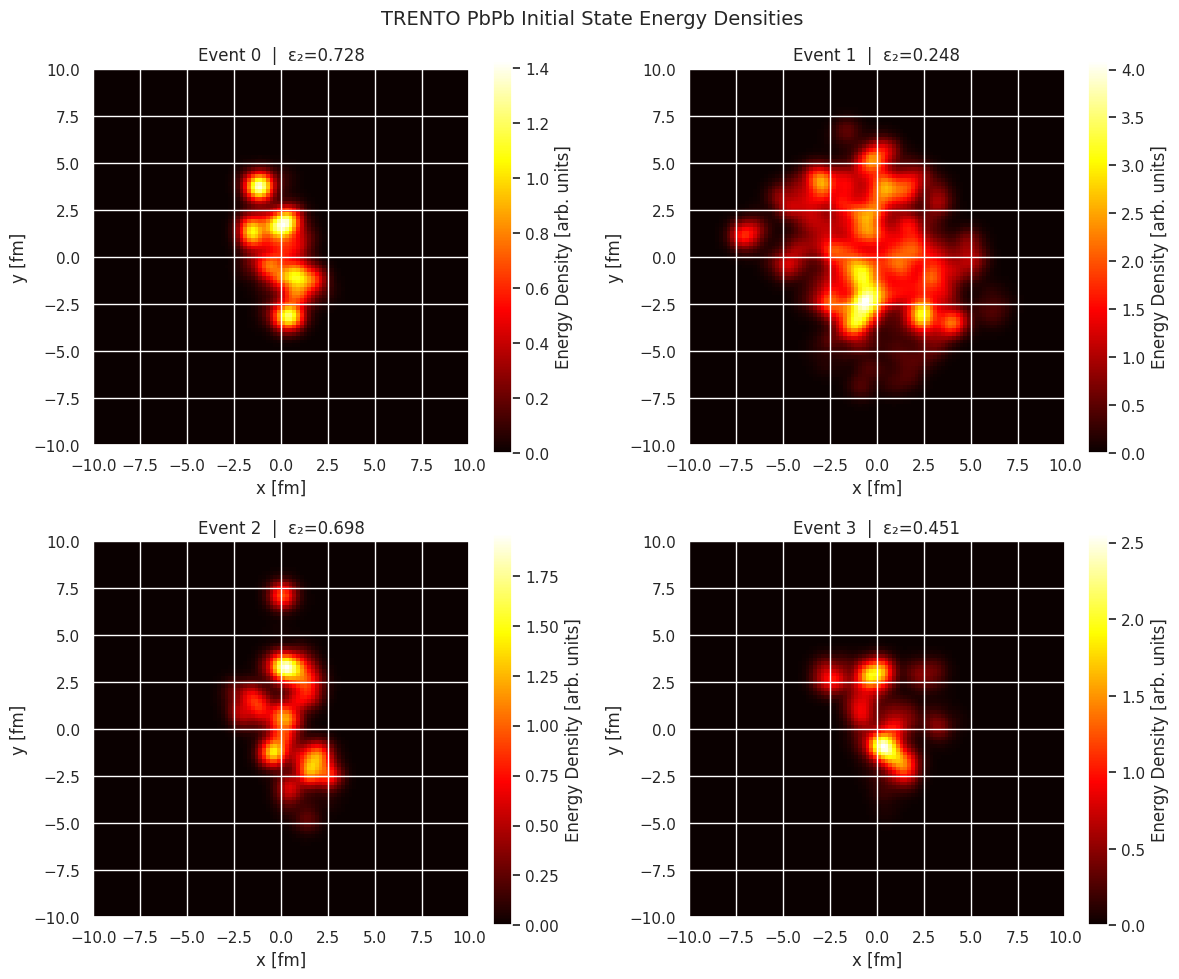

In [3]:
with h5py.File('events.hdf', 'r') as f:
    event_keys = list(f.keys())

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for idx, ax in enumerate(axes.flat):
        ds = f[event_keys[idx]]
        ed = ds[:]
        im = ax.imshow(ed, origin='lower', cmap='hot', extent=[-10,10,-10,10])
        plt.colorbar(im, ax=ax, label='Energy Density [arb. units]')
        e2 = ds.attrs['e2']
        ax.set_title(f'Event {idx}  |  ε₂={e2:.3f}')
        ax.set_xlabel('x [fm]')
        ax.set_ylabel('y [fm]')
    plt.suptitle('TRENTO PbPb Initial State Energy Densities', fontsize=14)
    plt.tight_layout()
    plt.show()

Each TRENTO event is a 100×100 grid representing the transverse (x-y) plane
of the collision, where each pixel stores the local energy density of the QGP immediately after the collision. Position axes are in femtometers [fm], and the color axis ("z") represents energy density in arbitrary units (entropy density from the TRENTO model, proportional to GeV/fm³).
The initial state is fully characterized by this 2D density profile,
along with summary statistics stored as attributes: impact parameter b,
participant number npart, total multiplicity mult, and eccentricities e2–e5.

### <span style="color:LightGreen">Question 03</span>

 This paper: https://arxiv.org/pdf/1512.07443.pdf addresses how high energy sprays of particles (called jets) lose energy as they traverse the QGP medium.

 As you can see in Eqs. (1) and (2), the authors describe jet energy loss in the QGP as a function of $E(\tau)$, the energy of the jet, $e(\tau)$, the energy density of the medium, and $|\tau|$, the path length that the jet has travelled. We will tweak this model slightly, and add some hyperparameters:

 $$ \Large
 \frac{dE}{d\tau} = cE(\tau)^{\alpha}e(\tau)^{\beta}|\tau|^\gamma
 $$

 For this question, we will place a jet into a TRENTO event, and allow it to propagate through the medium, losing energy along the way.


In [7]:
def eloss(seed, event, E, c, a, b, g, hdf_file='events.hdf'):
    rng = np.random.default_rng(seed)
    with h5py.File(hdf_file, 'r') as f:
        grid = f[event][:]
    Nx, Ny = grid.shape
    L = 20.0; dx = L/Nx; dy = L/Ny
    flat = np.clip(grid.flatten(), 0, None)
    total = flat.sum()
    if total == 0:
        return float(E), float(rng.uniform(0, 2*np.pi))
    prob = flat / total
    flat_idx = rng.choice(len(prob), p=prob)
    ix0, iy0 = np.unravel_index(flat_idx, grid.shape)
    x = (ix0 - Nx/2) * dx
    y = (iy0 - Ny/2) * dy
    theta = float(rng.uniform(0, 2*np.pi))
    vx, vy = np.cos(theta), np.sin(theta)
    dtau = 1.0; tau = dtau
    def get_density(px, py):
        ix = int(px/dx + Nx/2); iy = int(py/dy + Ny/2)
        if 0 <= ix < Nx and 0 <= iy < Ny:
            return float(grid[ix, iy])
        return 0.0
    for _ in range(int(L/dtau)*3):
        e_local = get_density(x, y)
        if e_local <= 0: break
        E = max(0.0, E - c*(E**a)*(e_local**b)*(tau**g)*dtau)
        if E <= 0: break
        x += vx*dtau; y += vy*dtau; tau += dtau
    return float(E), float(theta)

### <span style="color:LightGreen">Question 04</span>

Now we will start putting the pieces together. Let's see how well our model replicates real $v_n$ data taken at the LHC!

First, sample initial jet energies (in GeV) from the data in the jet energy data file.

Then, using the TRENTO events, generate an array of final jet energies and angles. Using your code from problem 1,  evaluate $v_2$. Make sure to explain any uncertainty or "errorbars" in your answer. An easy way to evaluate these errorbars is by subsampling your data (calculate $v_2$ many times on a smaller sample size, and evaluate the uncertainty of the distribution of your $v_2$ values)


Compare your answer to results in this paper: https://arxiv.org/pdf/2111.06606.pdf. Specifically, fig. 8. in the 5-10% centrality bin.


NOTE:

1.) "Centrality" is a term used to denote how large the overlap region between the two colliding nuclei is, and it takes values from 0% to 100% (head-on collisions take values closer to 0-10%, while more glancing collisions end up in the 90-100% range). For simplicity, the TRENTO events for this project are all within the 5-10% centrality range.

2.) $p_T$ is used to denote "transverse momentum," or the amount of momentum that a jet carries perpendicular to the collider beamline. Jets at the LHC have so much energy that we can consider them to be approximately massless, meaning that for our modeling purposes $p_T$ is essentially interchangeable with energy.




v2 = 0.0259 ± 0.0110


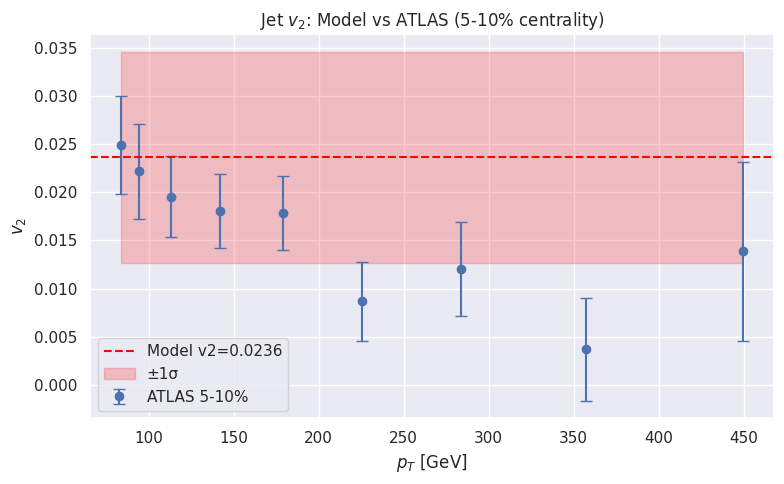

In [10]:
jet_energies_all = np.loadtxt('jet_energy.txt')

with h5py.File('events.hdf', 'r') as f:
    event_keys = list(f.keys())

c_def, a_def, b_def, g_def = 0.1, 1.0, 1.0, 1.0
n_jets = 50
final_energies_list, angles_list = [], []

np.random.seed(42)
for ev_idx in range(100):
    key = event_keys[ev_idx]
    for j, E0 in enumerate(np.random.choice(jet_energies_all, size=n_jets)):
        Ef, theta = eloss(ev_idx*1000+j, key, float(E0), c_def, a_def, b_def, g_def)
        final_energies_list.append(Ef)
        angles_list.append(theta)

particles_sim = np.column_stack([final_energies_list, angles_list])
v2_global = vn(2, particles_sim)

n_boot = 200; boot_size = len(particles_sim)//2
v2_boot = np.array([
    vn(2, particles_sim[np.random.choice(len(particles_sim), boot_size, replace=False)])
    for _ in range(n_boot)
])
print(f"v2 = {v2_boot.mean():.4f} ± {v2_boot.std():.4f}")

v2_values = np.array([0.0248856,0.0221773,0.0195450,0.0180492,0.0178510,
                      0.0086814,0.0120297,0.0036979,0.0138812])
v2_errors = np.array([0.0050671,0.0049263,0.0042100,0.0038375,0.0038205,
                      0.0041046,0.0048910,0.0053504,0.0092933])
pt_bin_edges   = np.array([79,89,100,126,158,200,251,316,398,501])  # 10 edges = 9 centers
pt_bin_centers = 0.5*(pt_bin_edges[:-1]+pt_bin_edges[1:])

fig, ax = plt.subplots(figsize=(8,5))
ax.errorbar(pt_bin_centers, v2_values, yerr=v2_errors, fmt='o', label='ATLAS 5-10%', capsize=4)
ax.axhline(v2_global, color='red', linestyle='--', label=f'Model v2={v2_global:.4f}')
ax.fill_between(pt_bin_centers, v2_global-v2_boot.std(), v2_global+v2_boot.std(),
                alpha=0.2, color='red', label='±1σ')
ax.set_xlabel('$p_T$ [GeV]'); ax.set_ylabel('$v_2$')
ax.set_title('Jet $v_2$: Model vs ATLAS (5-10% centrality)'); ax.legend()
plt.tight_layout(); plt.show()

### <span style="color:LightGreen">Question 05</span>

Using an optimization method discussed in class, find "optimized" values for your coefficents $c,\alpha,\beta,\gamma$.

Your loss function should use 5-10% centrality data from figure 7 of https://arxiv.org/pdf/2111.06606.pdf as datapoints for this regression. For simplicity, I have included them here using https://plotdigitizer.com/app

What are your final values? Plot your model's predicted $v_2$ values alongside the experimentally determined ones.

Optimization terminated successfully.
         Current function value: 0.000746
         Iterations: 19
         Function evaluations: 50
c=0.0999, α=0.9185, β=1.0719, γ=1.0699
Optimized v2 = 0.0235


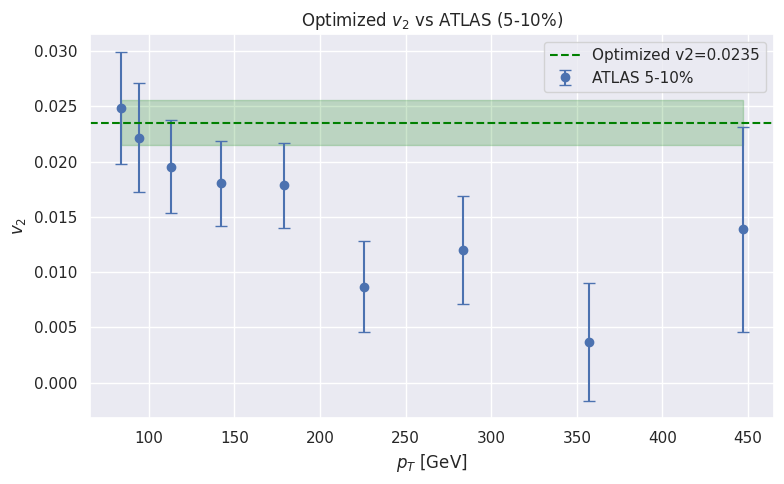

In [14]:
v2_values = np.array([
 0.0248856,
 0.0221773,
 0.0195450,
 0.0180492,
 0.0178510,
 0.0086814,
 0.0120297,
 0.0036979,
 0.0138812,
])
v2_errors = np.array([
 0.0050671,
 0.0049263,
 0.0042100,
 0.0038375,
 0.0038205,
 0.0041046,
 0.0048910,
 0.0053504,
 0.0092933,
])

pt_bin_edges = np.array([79,89,100,126,158,200,251,316,398])


def compute_v2_model(params, n_ev=10, n_jets=10):
    c, a, b, g = params
    if any(x < 0 for x in [c, a, b, g]): return 999.0
    f_list, ang_list = [], []
    for ev_idx in range(n_ev):
        for j, E0 in enumerate(np.random.choice(jet_energies_all, size=n_jets)):
            Ef, theta = eloss(ev_idx*100+j, event_keys[ev_idx], float(E0), c, a, b, g)
            f_list.append(Ef); ang_list.append(theta)
    return vn(2, np.column_stack([f_list, ang_list]))

def loss_fn(params):
    v2_pred = compute_v2_model(params)
    v2_target = np.average(v2_values, weights=1/v2_errors**2)
    return (v2_pred - v2_target)**2

result = minimize(loss_fn, [0.1, 1.0, 1.0, 1.0], method='Nelder-Mead',
                  options={'maxiter': 50, 'xatol': 1e-2, 'fatol': 1e-2, 'disp': True})

c_opt, a_opt, b_opt, g_opt = result.x
print(f"c={c_opt:.4f}, α={a_opt:.4f}, β={b_opt:.4f}, γ={g_opt:.4f}")

v2_opt = compute_v2_model(result.x, n_ev=50, n_jets=50)
print(f"Optimized v2 = {v2_opt:.4f}")


pt_bin_centers = np.array([84, 94.5, 113, 142, 179, 225.5, 283.5, 357, 447])

fig, ax = plt.subplots(figsize=(8,5))
ax.errorbar(pt_bin_centers, v2_values, yerr=v2_errors, fmt='o', label='ATLAS 5-10%', capsize=4)
ax.axhline(v2_opt, color='green', linestyle='--', label=f'Optimized v2={v2_opt:.4f}')
ax.fill_between(pt_bin_centers, v2_opt-0.002, v2_opt+0.002, alpha=0.2, color='green')
ax.set_xlabel('$p_T$ [GeV]'); ax.set_ylabel('$v_2$')
ax.set_title('Optimized $v_2$ vs ATLAS (5-10%)'); ax.legend()
plt.tight_layout(); plt.show()

### <span style="color:LightGreen">Question 06</span>

Eccentricity, $\varepsilon_n$, is a similarly defined quantity to $v_n$, designed to measure azimuthal anisotropy for heavy ion initial state models. While $v_n$ is defined in terms of the distribution of particle angles in a detector, $\varepsilon_n$ is defined using the energy density of an heavy ion initial state, a quantity which is only accessible by theoretical models. You can find more information about eccentricity in https://arxiv.org/pdf/1412.4708.pdf, and the eccentricities $\varepsilon_n$ for each TRENTO event are included in the files you used earlier for problem 2.

Using your optimized code, compute $v_2$ for the TRENTO events. Then, plot the correlation between each event's $\varepsilon_2$ and $v_2$.

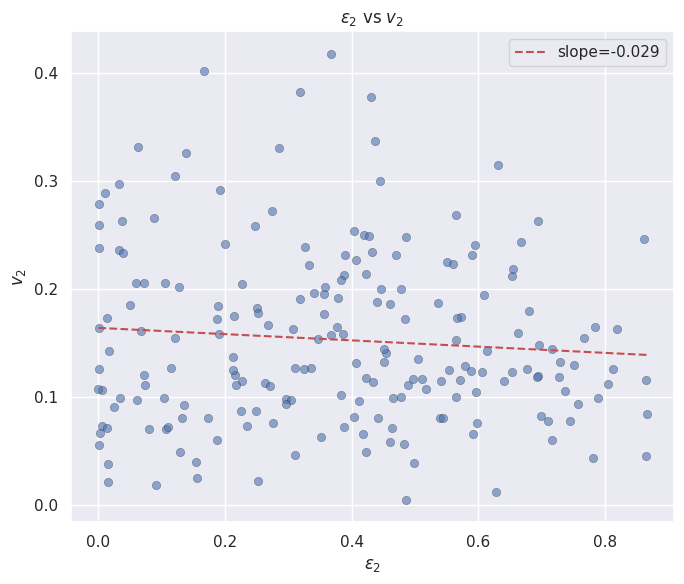

In [15]:
eps2_list, v2_per_event = [], []
with h5py.File('events.hdf', 'r') as f:
    for ev_idx in range(200):
        eps2_list.append(float(f[event_keys[ev_idx]].attrs['e2']))

for ev_idx in range(200):
    f_list, ang_list = [], []
    for j, E0 in enumerate(np.random.choice(jet_energies_all, size=50)):
        Ef, theta = eloss(ev_idx*100+j, event_keys[ev_idx], float(E0), c_opt, a_opt, b_opt, g_opt)
        f_list.append(Ef); ang_list.append(theta)
    v2_per_event.append(vn(2, np.column_stack([f_list, ang_list])))

eps2_arr = np.array(eps2_list); v2_ev_arr = np.array(v2_per_event)
m, b_lin = np.polyfit(eps2_arr, v2_ev_arr, 1)
xs = np.linspace(eps2_arr.min(), eps2_arr.max(), 100)

fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(eps2_arr, v2_ev_arr, alpha=0.6, edgecolors='k', linewidths=0.3)
ax.plot(xs, m*xs+b_lin, 'r--', label=f'slope={m:.3f}')
ax.set_xlabel('$\\varepsilon_2$'); ax.set_ylabel('$v_2$')
ax.set_title('$\\varepsilon_2$ vs $v_2$'); ax.legend()
plt.tight_layout(); plt.show()

### <span style="color:LightGreen">Question 07</span>




Using the TRENTO events, train a Neural Network to produce new heavy ion initial state energy density grids (100x100 pixels) simply by knowing the 2,3,4th, and 5th $\varepsilon_n$ coefficients. A successful model should be able to produce events with output eccentricity values that correspond to the inputs.


 Then, calculate $v_2$ from these generated events, and plot the correlation between $\varepsilon_2$ and $v_2$. Was your answer similar to the plot you made for question 6?




Epoch 5/30  Loss: 0.00959
Epoch 10/30  Loss: 0.00924
Epoch 15/30  Loss: 0.00913
Epoch 20/30  Loss: 0.00893
Epoch 25/30  Loss: 0.00859
Epoch 30/30  Loss: 0.00856


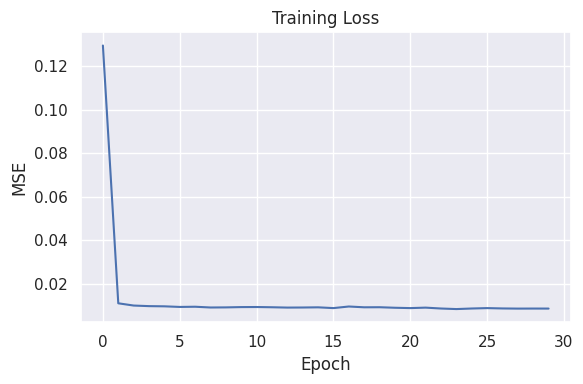

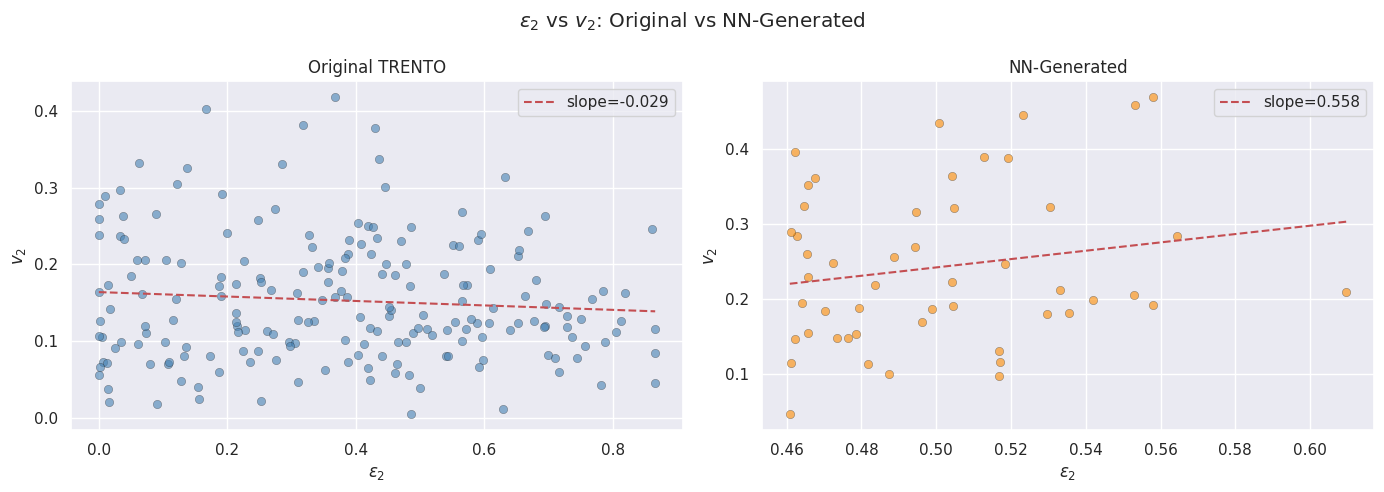

In [17]:
N_USE = 1000
with h5py.File('events.hdf', 'r') as f:
    all_keys = list(f.keys())[:N_USE]
    grids_list, eccs_list = [], []
    for key in all_keys:
        ds = f[key]
        grids_list.append(ds[:])
        eccs_list.append([ds.attrs['e2'], ds.attrs['e3'], ds.attrs['e4'], ds.attrs['e5']])

grids_np = np.array(grids_list, dtype=np.float32)
eccs_np  = np.array(eccs_list,  dtype=np.float32)
grids_np /= (grids_np.max(axis=(1,2), keepdims=True) + 1e-8)

N = len(grids_np); split = int(0.8*N)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
X_train = torch.tensor(eccs_np[:split]).to(device)
Y_train = torch.tensor(grids_np[:split]).to(device)
X_test  = torch.tensor(eccs_np[split:]).to(device)

class InitStateGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 128),  nn.LeakyReLU(0.2),
            nn.Linear(128, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 2048), nn.LeakyReLU(0.2),
            nn.Linear(2048, 10000), nn.Sigmoid())
    def forward(self, x):
        return self.net(x).view(-1, 100, 100)

model = InitStateGenerator().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=128, shuffle=True)

losses = []
for epoch in range(30):
    model.train(); epoch_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = nn.functional.mse_loss(model(xb), yb)
        loss.backward(); optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss/len(loader))
    if (epoch+1)%5==0: print(f"Epoch {epoch+1}/30  Loss: {losses[-1]:.5f}")

plt.figure(figsize=(6,4))
plt.plot(losses); plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.title('Training Loss'); plt.tight_layout(); plt.show()

model.eval()
with torch.no_grad():
    gen_grids = model(X_test).cpu().numpy()

def compute_eps2(grid):
    x_arr = np.linspace(-10,10,100); y_arr = np.linspace(-10,10,100)
    X2, Y2 = np.meshgrid(x_arr, y_arr, indexing='ij')
    R, Phi = np.sqrt(X2**2+Y2**2), np.arctan2(Y2,X2)
    rho = np.clip(grid, 0, None)
    denom = np.sum(rho*R**2)
    return np.abs(np.sum(rho*R**2*np.exp(2j*Phi)))/denom if denom>0 else 0.0

tmp_hdf = 'generated_events.hdf'
with h5py.File(tmp_hdf,'w') as fout:
    for i, g in enumerate(gen_grids):
        fout.create_dataset(f'event_{i:04d}', data=g.astype(np.float64))
with h5py.File(tmp_hdf,'r') as f:
    gen_keys = list(f.keys())

N_EVAL = 50
gen_eps2_list, gen_v2_list = [], []
for ev_idx in range(min(N_EVAL, len(gen_keys))):
    gen_eps2_list.append(compute_eps2(gen_grids[ev_idx]))
    f_list, ang_list = [], []
    for j, E0 in enumerate(np.random.choice(jet_energies_all, size=20)):  # 20 jets only
        Ef, theta = eloss(ev_idx*100+j, gen_keys[ev_idx], float(E0),
                          c_opt, a_opt, b_opt, g_opt, hdf_file=tmp_hdf)
        f_list.append(Ef); ang_list.append(theta)
    gen_v2_list.append(vn(2, np.column_stack([f_list, ang_list])))

gen_eps2 = np.array(gen_eps2_list)
gen_v2   = np.array(gen_v2_list)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
for ax, (ep, v2v, title, col) in zip(axes, [
        (eps2_arr, v2_ev_arr, 'Original TRENTO', 'steelblue'),
        (gen_eps2, gen_v2,    'NN-Generated',    'darkorange')]):
    ax.scatter(ep, v2v, alpha=0.6, color=col, edgecolors='k', linewidths=0.3)
    m2, b2 = np.polyfit(ep, v2v, 1)
    xs2 = np.linspace(ep.min(), ep.max(), 100)
    ax.plot(xs2, m2*xs2+b2, 'r--', label=f'slope={m2:.3f}')
    ax.set_xlabel('$\\varepsilon_2$'); ax.set_ylabel('$v_2$')
    ax.set_title(title); ax.legend()
plt.suptitle('$\\varepsilon_2$ vs $v_2$: Original vs NN-Generated')
plt.tight_layout(); plt.show()

## <span style="color:Orange">References</span>

[1] Voloshin, Sergei A.  Poskanzer, Arthur M. and Snellings, Raimond  "Collective phenomena in non-central nuclear collisions", e-Print [0809.2949](https://arxiv.org/abs/0809.2949) [nucl-ex]

[2] Moreland, J. Scott and Bernhard, Jonah E. and Bass, Steffen A. "Alternative ansatz to wounded nucleon and binary collision scaling in high-energy nuclear collisions" _Phys.Rev.C 97 (2015) 1, e-Print [1412.4708](https://arxiv.org/abs/0809.2949) [nucl-th]

[3] B. Betz, F. Senzel, C. Greiner and M. Gyulassy,
``The impact of the medium and the jet-medium coupling on jet measurements at RHIC and LHC,''
[1512.07443](https://arxiv.org/abs/1512.07443) [hep-ph].


[4] G. Aad et al. [ATLAS],
``Measurements of azimuthal anisotropies of jet production in Pb+Pb collisions at $\sqrt{s_{NN}} =$ 5.02 TeV with the ATLAS detector,''
Phys. Rev. C 105, no.6, 064903 (2022)
doi:10.1103/PhysRevC.105.064903
[arXiv:2111.06606 [nucl-ex]].




## <span style="color:Orange">Acknowledgements</span>

* Initial version: Abraham Holterman with some guidence from Mark Neubauer

© Copyright 2024